# Benchmark Comparison for the MHAR Feature Set

This notebook consolidates the one-day-ahead out-of-sample forecast results for the MHAR feature set across the model classes used in the thesis. The structure follows the same step-by-step format as the benchmark and regularized-model notebooks: we load the saved forecasts, align the evaluation sample, compute headline forecast metrics, run Diebold-Mariano (DM) comparisons, visualize error distributions, and finish with a subperiod analysis that isolates the 2020 volatility regime.

The primary objective is to produce a thesis-ready comparison of the benchmark, regularized linear, tree-based, and neural-network models on a common MHAR test sample.

## 1. Setup and Scope

We begin by defining the model universe and pointing the notebook to the saved forecast artifacts under `Cleaned Data/Forcasts/MHAR`. To keep the headline comparison readable, the notebook uses one result per model family. For the tree-based models, the retained Gradient Boosting and Bagging results are the exploratory versions that were executed under the same rolling MHAR setup but with lighter computational settings than the full reference-paper design. We return to the meaning of the exploratory label at the end of the notebook.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.6e}')

forecast_path = Path('/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR')
data_path = Path('/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv')

model_specs = [
    {'key': 'HAR', 'label': 'HAR', 'family': 'Benchmark'},
    {'key': 'LogHAR', 'label': 'LogHAR', 'family': 'Benchmark'},
    {'key': 'LevHAR', 'label': 'LevHAR', 'family': 'Benchmark'},
    {'key': 'SHAR', 'label': 'SHAR', 'family': 'Benchmark'},
    {'key': 'HARQ', 'label': 'HARQ', 'family': 'Benchmark'},
    {'key': 'RR', 'label': 'RR', 'family': 'Regularized Linear'},
    {'key': 'LA', 'label': 'LASSO', 'family': 'Regularized Linear'},
    {'key': 'EN', 'label': 'EN', 'family': 'Regularized Linear'},
    {'key': 'RF', 'label': 'RF', 'family': 'Tree-Based'},
    {'key': 'BG_exploratory', 'label': 'BG (Exploratory)', 'family': 'Tree-Based'},
    {'key': 'GB_exploratory', 'label': 'GB (Exploratory)', 'family': 'Tree-Based'},
    {'key': 'NN1', 'label': 'NN1', 'family': 'Neural Network'},
]

supplementary_specs = [
    {'key': 'BG', 'label': 'BG (Full)', 'family': 'Tree-Based'},
]

model_key_to_label = {spec['key']: spec['label'] for spec in model_specs + supplementary_specs}
label_to_key = {spec['label']: spec['key'] for spec in model_specs + supplementary_specs}
model_keys = [spec['key'] for spec in model_specs]


family_colors = {
    'Benchmark': '#4C78A8',
    'Regularized Linear': '#F58518',
    'Tree-Based': '#54A24B',
    'Neural Network': '#B279A2',
}


## 2. Load Forecast Files and Harmonize the Evaluation Window

The saved CSV files are not all indexed in exactly the same way, so we standardize the date column first and then align all models to the common overlapping test window. This matters because pairwise DM tests and cross-model metrics should be computed on the same observations. In the saved artifacts, the HAR file is date-stamped one day earlier than the other models, so using the common overlap prevents an accidental mismatch in the benchmark comparison.

In [7]:
def load_forecast_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    date_col = 'Date' if 'Date' in df.columns else df.columns[0]
    df = df.rename(columns={date_col: 'Date'})[['Date', 'RV_actual', 'RV_forecast']].copy()
    df['Date'] = pd.to_datetime(df['Date'])
    return df.set_index('Date').sort_index()

results = {
    spec['key']: load_forecast_file(forecast_path / f"forecasts_{spec['key']}.csv")
    for spec in model_specs
}

common_index = None
for df in results.values():
    common_index = df.index if common_index is None else common_index.intersection(df.index)
common_index = common_index.sort_values()

results = {key: df.reindex(common_index).copy() for key, df in results.items()}
actual_series = next(iter(results.values()))['RV_actual']

alignment_rows = []
for spec in model_specs:
    df = results[spec['key']]
    alignment_rows.append({
        'Model': spec['label'],
        'Family': spec['family'],
        'Observations': len(df),
        'Start': df.index.min().date(),
        'End': df.index.max().date(),
    })

alignment_table = pd.DataFrame(alignment_rows)
display(alignment_table)
print(f'Common evaluation window: {common_index.min().date()} to {common_index.max().date()} ({len(common_index)} observations)')


,Model,Family,Observations,Start,End
0,HAR,Benchmark,1098,2016-04-21,2020-08-05
1,LogHAR,Benchmark,1098,2016-04-21,2020-08-05
2,LevHAR,Benchmark,1098,2016-04-21,2020-08-05
3,SHAR,Benchmark,1098,2016-04-21,2020-08-05
4,HARQ,Benchmark,1098,2016-04-21,2020-08-05
5,RR,Regularized Linear,1098,2016-04-21,2020-08-05
6,LASSO,Regularized Linear,1098,2016-04-21,2020-08-05
7,EN,Regularized Linear,1098,2016-04-21,2020-08-05
8,RF,Tree-Based,1098,2016-04-21,2020-08-05
9,BG (Exploratory),Tree-Based,1098,2016-04-21,2020-08-05


Common evaluation window: 2016-04-21 to 2020-08-05 (1098 observations)


## 3. Recover the 70/10/20 Split and Build the Historical-Mean Benchmark

The $R_o^2$ statistic requires a benchmark forecast. Following the spirit of the reference paper, we benchmark each model against a simple historical-mean forecast where the mean is estimated only on the in-sample portion used for model development, i.e. the combined training and validation sample. This gives a constant benchmark forecast for the test period:

$$
R_o^2 = 1 - \frac{\sum_{t \in \mathcal{T}} (RV_t - \widehat{RV}_{t,\,model})^2}{\sum_{t \in \mathcal{T}} (RV_t - \bar{RV}_{train+val})^2}.
$$

Using the same 70/10/20 split as in the MHAR modeling notebooks keeps the benchmark directly comparable to the individual model evaluations.

In [11]:
mall = pd.read_csv(data_path, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)

n_total = len(mall)
n_train = int(np.floor(0.70 * n_total))
n_val = int(np.floor(0.10 * n_total))
n_test = n_total - n_train - n_val

train_start, train_end = mall.loc[0, 'Date'], mall.loc[n_train - 1, 'Date']
val_start, val_end = mall.loc[n_train, 'Date'], mall.loc[n_train + n_val - 1, 'Date']
test_start, test_end = mall.loc[n_train + n_val, 'Date'], mall.loc[n_total - 1, 'Date']

historical_mean = mall.loc[: n_train + n_val - 1, 'RV_target'].mean()
benchmark_test = mall.loc[n_train + n_val :, ['Date', 'RV_target']].copy()
benchmark_test = benchmark_test.set_index('Date').reindex(common_index)
benchmark_test['RV_historical_mean'] = historical_mean
benchmark_mse = np.mean((benchmark_test['RV_target'] - benchmark_test['RV_historical_mean']) ** 2)

print(f'Total sample:      {mall.loc[0, "Date"].date()} to {mall.loc[n_total - 1, "Date"].date()} ({n_total} observations)')
print(f'Training sample:   {train_start.date()} to {train_end.date()} ({n_train} observations)')
print(f'Validation sample: {val_start.date()} to {val_end.date()} ({n_val} observations)')
print(f'Test sample:       {test_start.date()} to {test_end.date()} ({n_test} observations)')
print(f'Historical mean benchmark (train + validation): {historical_mean:.6e}')
print(f'Benchmark MSE on aligned comparison window:     {benchmark_mse:.6e}')


Total sample:      1999-01-05 to 2020-08-06 (5489 observations)
Training sample:   1999-01-05 to 2014-02-26 (3842 observations)
Validation sample: 2014-02-27 to 2016-04-20 (548 observations)
Test sample:       2016-04-21 to 2020-08-06 (1099 observations)
Historical mean benchmark (train + validation): 1.615540e-04
Benchmark MSE on aligned comparison window:     6.744222e-08


## 4. Headline Performance Table

We now compute the main evaluation metrics on the aligned MHAR comparison window. The table below is designed to serve as the notebook's headline summary: it reports MSE, RMSE, MAE, mean forecast error, relative MSE versus HAR, and $R_o^2$ versus the historical-mean benchmark. Models are ranked by MSE, so lower values indicate better forecast accuracy under squared-error loss.

In [14]:
summary_rows = []
for spec in model_specs:
    df = results[spec['key']]
    errors = df['RV_actual'] - df['RV_forecast']
    mse = np.mean(errors ** 2)
    summary_rows.append({
        'Model': spec['label'],
        'Family': spec['family'],
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': np.mean(np.abs(errors)),
        'Mean Error': np.mean(errors),
        'R_o^2': 1 - (np.sum(errors ** 2) / np.sum((benchmark_test['RV_target'] - benchmark_test['RV_historical_mean']) ** 2)),
    })

summary_metrics = pd.DataFrame(summary_rows).sort_values('MSE').reset_index(drop=True)
summary_metrics['Rank'] = np.arange(1, len(summary_metrics) + 1)
har_mse = summary_metrics.loc[summary_metrics['Model'] == 'HAR', 'MSE'].iloc[0]
summary_metrics['Relative MSE vs HAR'] = summary_metrics['MSE'] / har_mse
summary_metrics = summary_metrics[['Rank', 'Model', 'Family', 'MSE', 'RMSE', 'MAE', 'Mean Error', 'Relative MSE vs HAR', 'R_o^2']]

display(
    summary_metrics.style.format({
        'MSE': '{:.6e}',
        'RMSE': '{:.6e}',
        'MAE': '{:.6e}',
        'Mean Error': '{:.6e}',
        'Relative MSE vs HAR': '{:.4f}',
        'R_o^2': '{:.4%}',
    }).set_caption('Table 1: Test-Set Forecast Performance Summary — MHAR Models')
)


,Rank,Model,Family,MSE,RMSE,MAE,Mean Error,Relative MSE vs HAR,R_o^2
0,1,HARQ,Benchmark,2.137291e-08,1.461948e-04,5.496036e-05,-2.054823e-06,0.9613,68.3093%
1,2,LevHAR,Benchmark,2.148244e-08,1.465689e-04,5.682854e-05,3.209017e-06,0.9662,68.1469%
2,3,RF,Tree-Based,2.201041e-08,1.483590e-04,5.427150e-05,-1.287721e-06,0.9900,67.3641%
3,4,BG (Exploratory),Tree-Based,2.217241e-08,1.489040e-04,5.515754e-05,-2.359583e-06,0.9973,67.1238%
4,5,HAR,Benchmark,2.223326e-08,1.491082e-04,5.595880e-05,-4.078708e-06,1.0000,67.0336%
5,6,RR,Regularized Linear,2.239252e-08,1.496413e-04,5.623599e-05,-4.418608e-06,1.0072,66.7975%
6,7,SHAR,Benchmark,2.240441e-08,1.496810e-04,5.597150e-05,-4.192384e-06,1.0077,66.7798%
7,8,LASSO,Regularized Linear,2.381999e-08,1.543372e-04,6.412984e-05,-1.164366e-05,1.0714,64.6809%
8,9,EN,Regularized Linear,2.383659e-08,1.543910e-04,6.417884e-05,-1.168123e-05,1.0721,64.6563%
9,10,GB (Exploratory),Tree-Based,2.459544e-08,1.568293e-04,7.304952e-05,-2.110458e-05,1.1062,63.5311%


## 5. Reference-Paper Style Relative-MSE Table and Diebold-Mariano Tests

The reference paper emphasizes relative forecast performance and formal pairwise comparisons. To mirror that presentation, we build a matrix in which each cell reports the relative MSE of the column model against the row model, i.e. `column MSE / row MSE`. Values below one therefore favor the column model. We also compute one-sided Diebold-Mariano tests under squared-error loss, where the alternative hypothesis is that the column model is more accurate than the row model.

Stars indicate one-sided significance in favor of the column model: `*` for 10\%, `**` for 5\%, and `***` for 1\%.

In [17]:
def diebold_mariano_test(e1: np.ndarray, e2: np.ndarray, h: int = 1) -> tuple[float, float]:
    d = e1**2 - e2**2
    d_bar = d.mean()
    T = len(d)
    nlags = int(np.floor(T ** (1/3)))  # rule of thumb: T^(1/3) lags
    nw = sm.stats.sandwich_covariance.cov_hac_simple(
        sm.OLS(d, np.ones(T)).fit(),
        nlags=nlags,
    )
    se = np.sqrt(nw[0, 0] / T)
    dm_stat = d_bar / se
    p_val = 1 - stats.norm.cdf(dm_stat)
    return float(dm_stat), float(p_val)

def significance_stars(p_value: float) -> str:
    if p_value < 0.01:
        return '***'
    if p_value < 0.05:
        return '**'
    if p_value < 0.10:
        return '*'
    return ''

# Define custom display order
display_order = [
    'HAR', 'LogHAR', 'LevHAR', 'SHAR', 'HARQ',
    'RR', 'LASSO', 'EN',
    'BG (Exploratory)', 'GB (Exploratory)', 'RF',
    'NN1'
]

# Reorder all matrices according to display order
ordered_labels = display_order
ordered_keys   = [label_to_key[label] for label in ordered_labels]

relative_mse_numeric = pd.DataFrame(index=ordered_labels, columns=ordered_labels, dtype=float)
dm_stat_matrix       = pd.DataFrame(index=ordered_labels, columns=ordered_labels, dtype=float)
dm_pval_matrix       = pd.DataFrame(index=ordered_labels, columns=ordered_labels, dtype=float)
paper_style_table    = pd.DataFrame(index=ordered_labels, columns=ordered_labels, dtype=object)

for row_label, row_key in zip(ordered_labels, ordered_keys):
    e_row   = results[row_key]['RV_actual'].values - results[row_key]['RV_forecast'].values
    mse_row = np.mean(e_row**2)
    for col_label, col_key in zip(ordered_labels, ordered_keys):
        if row_key == col_key:
            relative_mse_numeric.loc[row_label, col_label] = np.nan
            dm_stat_matrix.loc[row_label, col_label]       = np.nan
            dm_pval_matrix.loc[row_label, col_label]       = np.nan
            paper_style_table.loc[row_label, col_label]    = '–'
            continue
        e_col   = results[col_key]['RV_actual'].values - results[col_key]['RV_forecast'].values
        mse_col = np.mean(e_col**2)
        ratio   = mse_col / mse_row
        dm_stat, dm_pval = diebold_mariano_test(e_row, e_col, h=1)
        stars   = significance_stars(dm_pval) if ratio < 1 else ''
        relative_mse_numeric.loc[row_label, col_label] = ratio
        dm_stat_matrix.loc[row_label, col_label]       = dm_stat
        dm_pval_matrix.loc[row_label, col_label]       = dm_pval
        paper_style_table.loc[row_label, col_label]    = f'{ratio:.3f}{stars}'

display(
    paper_style_table.style.set_caption(
        'Table 2: Relative MSE (Column / Row) with One-Sided DM Significance'
    )
)
display(
    dm_stat_matrix.style.format('{:.3f}').set_caption(
        'Table 3: One-Sided Diebold-Mariano Test Statistics (Alternative: Column Model Better Than Row Model)'
    )
)

,HAR,LogHAR,LevHAR,SHAR,HARQ,RR,LASSO,EN,BG (Exploratory),GB (Exploratory),RF,NN1
HAR,–,1.137,0.966***,1.008,0.961***,1.007,1.071,1.072,0.997,1.106,0.990***,1.597
LogHAR,0.879***,–,0.850***,0.886***,0.845***,0.886***,0.942***,0.943***,0.877***,0.973***,0.871***,1.405
LevHAR,1.035,1.177,–,1.043,0.995***,1.042,1.109,1.110,1.032,1.145,1.025,1.653
SHAR,0.992***,1.128,0.959***,–,0.954***,0.999*,1.063,1.064,0.990***,1.098,0.982***,1.585
HARQ,1.040,1.183,1.005,1.048,–,1.048,1.114,1.115,1.037,1.151,1.030,1.662
RR,0.993***,1.129,0.959***,1.001,0.954***,–,1.064,1.064,0.990***,1.098,0.983***,1.586
LASSO,0.933***,1.061,0.902***,0.941***,0.897***,0.940***,–,1.001,0.931***,1.033,0.924***,1.491
EN,0.933***,1.061,0.901***,0.940***,0.897***,0.939***,0.999***,–,0.930***,1.032,0.923***,1.490
BG (Exploratory),1.003,1.140,0.969***,1.010,0.964***,1.010,1.074,1.075,–,1.109,0.993***,1.602
GB (Exploratory),0.904***,1.028,0.873***,0.911***,0.869***,0.910***,0.968***,0.969***,0.901***,–,0.895***,1.444


,HAR,LogHAR,LevHAR,SHAR,HARQ,RR,LASSO,EN,BG (Exploratory),GB (Exploratory),RF,NN1
HAR,nan,-27.193,23.835,-34.748,28.978,-29.198,-28.951,-29.052,1.049,-47.543,8.265,-38.633
LogHAR,27.193,nan,27.241,25.703,28.370,27.051,24.779,24.660,19.570,10.566,25.613,-42.855
LevHAR,-23.835,-27.241,nan,-29.733,4.258,-25.077,-28.432,-28.503,-13.730,-39.855,-14.659,-38.060
SHAR,34.748,-25.703,29.733,nan,32.256,1.596,-25.817,-25.941,3.965,-43.560,13.555,-38.228
HARQ,-28.978,-28.370,-4.258,-32.256,nan,-29.683,-29.940,-30.006,-20.919,-43.038,-32.067,-38.608
RR,29.198,-27.051,25.077,-1.596,29.683,nan,-28.769,-28.882,3.554,-49.509,12.814,-38.725
LASSO,28.951,-24.779,28.432,25.817,29.940,28.769,nan,-42.168,15.370,-49.963,24.384,-39.651
EN,29.052,-24.660,28.503,25.941,30.006,28.882,42.168,nan,15.476,-48.447,24.493,-39.645
BG (Exploratory),-1.049,-19.570,13.730,-3.965,20.919,-3.554,-15.370,-15.476,nan,-24.682,4.638,-35.238
GB (Exploratory),47.543,-10.566,39.855,43.560,43.038,49.509,49.963,48.447,24.682,nan,39.593,-36.481


## 6. Distribution of Daily Squared Forecast Errors

MSE is an average, so it is informative to inspect the cross-sectional distribution of the daily squared forecast errors that build up each model's test-set MSE. The boxplot below therefore summarizes the dispersion, skewness, and outlier sensitivity of squared errors across the aligned test period.

/var/folders/ym/wl40dz313jq5xxzrl0tc87w00000gn/T/ipykernel_41908/1693268787.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(squared_error_data, labels=ordered_labels, showfliers=False, patch_artist=True)


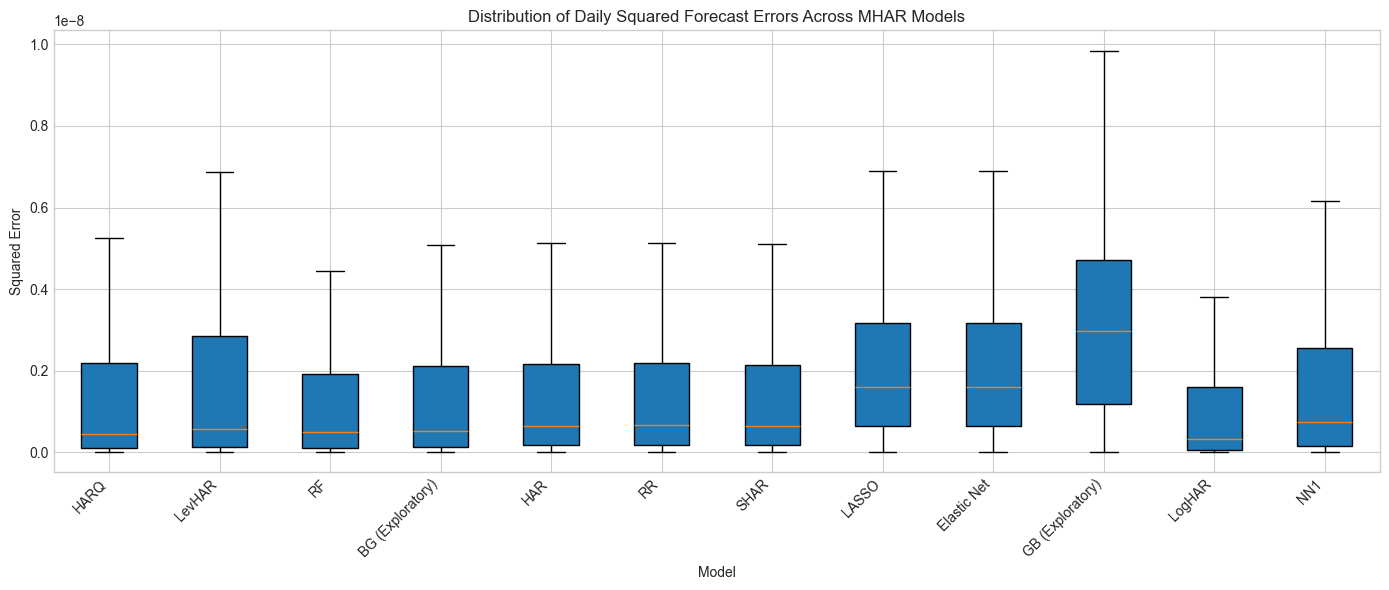

In [6]:
squared_error_data = []
for label, key in zip(ordered_labels, ordered_keys):
    errors = results[key]['RV_actual'] - results[key]['RV_forecast']
    squared_error_data.append(errors.pow(2).values)

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(squared_error_data, labels=ordered_labels, showfliers=False, patch_artist=True)
for patch in ax.artists:
    patch.set_facecolor('#d9e6f2')
ax.set_title('Distribution of Daily Squared Forecast Errors Across MHAR Models')
ax.set_ylabel('Squared Error')
ax.set_xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. $R_o^2$ Relative to the Historical Mean

The $R_o^2$ measure summarizes the proportional reduction in out-of-sample squared prediction error relative to the historical-mean benchmark. Positive values indicate that a model improves on the benchmark, while higher values indicate larger gains. Ranking models by $R_o^2$ is useful because it reframes forecast performance in terms of economic benchmarking rather than only absolute error magnitudes.

In [7]:
ro2_table = summary_metrics[['Model', 'Family', 'R_o^2']].copy().sort_values('R_o^2', ascending=False).reset_index(drop=True)
ro2_table['Rank by R_o^2'] = np.arange(1, len(ro2_table) + 1)
ro2_table = ro2_table[['Rank by R_o^2', 'Model', 'Family', 'R_o^2']]

display(
    ro2_table.style.format({'R_o^2': '{:.4%}'}).set_caption(
        'Table 4: Ranking by R_o^2 Relative to the Historical Mean Benchmark'
    )
)


,Rank by R_o^2,Model,Family,R_o^2
0,1,HARQ,Benchmark,68.3093%
1,2,LevHAR,Benchmark,68.1469%
2,3,RF,Tree-Based,67.3641%
3,4,BG (Exploratory),Tree-Based,67.1238%
4,5,HAR,Benchmark,67.0336%
5,6,RR,Regularized Linear,66.7975%
6,7,SHAR,Benchmark,66.7798%
7,8,LASSO,Regularized Linear,64.6809%
8,9,Elastic Net,Regularized Linear,64.6563%
9,10,GB (Exploratory),Tree-Based,63.5311%


## 8. Subperiod Analysis: Before 2020 versus During 2020

To understand whether model rankings are stable across volatility regimes, we split the aligned test window into a pre-2020 subperiod and a 2020 subperiod. The latter captures the Covid-19 volatility shock and therefore puts more weight on crisis-period forecast behavior. This decomposition helps reveal whether some models perform relatively better in calmer conditions than in the extreme regime shift of 2020.

In [8]:
subperiods = {
    'Pre-2020': common_index[common_index < pd.Timestamp('2020-01-01')],
    'During 2020': common_index[common_index >= pd.Timestamp('2020-01-01')],
}

subperiod_tables = {}
for name, sub_index in subperiods.items():
    rows = []
    benchmark_sub = benchmark_test.loc[sub_index]
    benchmark_sse = np.sum((benchmark_sub['RV_target'] - benchmark_sub['RV_historical_mean']) ** 2)
    for spec in model_specs:
        df = results[spec['key']].loc[sub_index]
        errors = df['RV_actual'] - df['RV_forecast']
        mse = np.mean(errors ** 2)
        rows.append({
            'Model': spec['label'],
            'Family': spec['family'],
            'MSE': mse,
            'RMSE': np.sqrt(mse),
            'MAE': np.mean(np.abs(errors)),
            'Mean Error': np.mean(errors),
            'R_o^2': 1 - (np.sum(errors ** 2) / benchmark_sse),
        })
    table = pd.DataFrame(rows).sort_values('MSE').reset_index(drop=True)
    table['Rank'] = np.arange(1, len(table) + 1)
    har_sub_mse = table.loc[table['Model'] == 'HAR', 'MSE'].iloc[0]
    table['Relative MSE vs HAR'] = table['MSE'] / har_sub_mse
    table = table[['Rank', 'Model', 'Family', 'MSE', 'RMSE', 'MAE', 'Mean Error', 'Relative MSE vs HAR', 'R_o^2']]
    subperiod_tables[name] = table

for name, table in subperiod_tables.items():
    display(
        table.style.format({
            'MSE': '{:.6e}',
            'RMSE': '{:.6e}',
            'MAE': '{:.6e}',
            'Mean Error': '{:.6e}',
            'Relative MSE vs HAR': '{:.4f}',
            'R_o^2': '{:.4%}',
        }).set_caption(f'{name}: Forecast Performance Summary')
    )

comparison_table = subperiod_tables['Pre-2020'][['Model', 'MSE', 'Rank']].rename(
    columns={'MSE': 'MSE Pre-2020', 'Rank': 'Rank Pre-2020'}
).merge(
    subperiod_tables['During 2020'][['Model', 'MSE', 'Rank']].rename(
        columns={'MSE': 'MSE During 2020', 'Rank': 'Rank During 2020'}
    ),
    on='Model'
)
comparison_table['Change in Rank (2020 - Pre-2020)'] = comparison_table['Rank During 2020'] - comparison_table['Rank Pre-2020']

display(
    comparison_table.sort_values('Rank During 2020').style.format({
        'MSE Pre-2020': '{:.6e}',
        'MSE During 2020': '{:.6e}',
    }).set_caption('Table 5: Rank Changes from Pre-2020 to the 2020 Volatility Regime')
)


,Rank,Model,Family,MSE,RMSE,MAE,Mean Error,Relative MSE vs HAR,R_o^2
0,1,LogHAR,Benchmark,8.931915e-09,9.450881e-05,3.129194e-05,6.479203e-06,0.9079,54.9624%
1,2,NN1,Neural Network,9.047225e-09,9.511690e-05,3.857209e-05,-1.235306e-05,0.9196,54.3809%
2,3,RF,Tree-Based,9.397083e-09,9.693855e-05,3.510713e-05,-4.262303e-06,0.9551,52.6168%
3,4,HARQ,Benchmark,9.643449e-09,9.820107e-05,3.565139e-05,-4.712065e-06,0.9802,51.3746%
4,5,RR,Regularized Linear,9.794360e-09,9.896646e-05,3.754819e-05,-9.953961e-06,0.9955,50.6136%
5,6,HAR,Benchmark,9.838407e-09,9.918874e-05,3.726923e-05,-9.382203e-06,1.0000,50.3915%
6,7,BG (Exploratory),Tree-Based,9.850128e-09,9.924781e-05,3.598466e-05,-4.718375e-06,1.0012,50.3324%
7,8,LASSO,Regularized Linear,9.997006e-09,9.998503e-05,4.693999e-05,-2.490585e-05,1.0161,49.5918%
8,9,SHAR,Benchmark,9.997968e-09,9.998984e-05,3.726065e-05,-9.522678e-06,1.0162,49.5870%
9,10,Elastic Net,Regularized Linear,9.999108e-09,9.999554e-05,4.699593e-05,-2.498131e-05,1.0163,49.5812%


,Rank,Model,Family,MSE,RMSE,MAE,Mean Error,Relative MSE vs HAR,R_o^2
0,1,LevHAR,Benchmark,8.956170e-08,2.992686e-04,1.660609e-04,2.665855e-05,0.9013,75.3784%
1,2,HARQ,Benchmark,9.437340e-08,3.072025e-04,1.751333e-04,1.448301e-05,0.9497,74.0556%
2,3,BG (Exploratory),Tree-Based,9.886238e-08,3.144239e-04,1.744835e-04,1.232080e-05,0.9948,72.8215%
3,4,HAR,Benchmark,9.937494e-08,3.152379e-04,1.722768e-04,2.892857e-05,1.0000,72.6806%
4,5,SHAR,Benchmark,9.961821e-08,3.156235e-04,1.724219e-04,2.898168e-05,1.0024,72.6137%
5,6,RF,Tree-Based,1.005117e-07,3.170359e-04,1.735445e-04,1.722514e-05,1.0114,72.3681%
6,7,RR,Regularized Linear,1.007995e-07,3.174894e-04,1.725430e-04,3.003168e-05,1.0143,72.2890%
7,8,LASSO,Regularized Linear,1.098498e-07,3.314360e-04,1.711140e-04,7.089602e-05,1.1054,69.8009%
8,9,Elastic Net,Regularized Linear,1.099567e-07,3.315972e-04,1.711199e-04,7.109428e-05,1.1065,69.7716%
9,10,GB (Exploratory),Tree-Based,1.109036e-07,3.330219e-04,1.726589e-04,7.307940e-05,1.1160,69.5113%


,Model,MSE Pre-2020,Rank Pre-2020,MSE During 2020,Rank During 2020,Change in Rank (2020 - Pre-2020)
10,LevHAR,1.054369e-08,11,8.956170e-08,1,-10
3,HARQ,9.643449e-09,4,9.437340e-08,2,-2
6,BG (Exploratory),9.850128e-09,7,9.886238e-08,3,-4
5,HAR,9.838407e-09,6,9.937494e-08,4,-2
8,SHAR,9.997968e-09,9,9.961821e-08,5,-4
2,RF,9.397083e-09,3,1.005117e-07,6,3
4,RR,9.794360e-09,5,1.007995e-07,7,2
7,LASSO,9.997006e-09,8,1.098498e-07,8,0
9,Elastic Net,9.999108e-09,10,1.099567e-07,9,-1
11,GB (Exploratory),1.072776e-08,12,1.109036e-07,10,-2


## 9. Family-Colored $R_o^2$ Bar Charts Across Periods

To make the benchmark comparison visually consistent across periods, we now plot $R_o^2$ for the full aligned test sample, the pre-2020 period, and the 2020 subperiod using the same family-based color scheme. The x-axis always shows model labels, while the legend groups models into the four broad classes used in the thesis: benchmark models, regularized linear models, tree-based models, and the neural network.

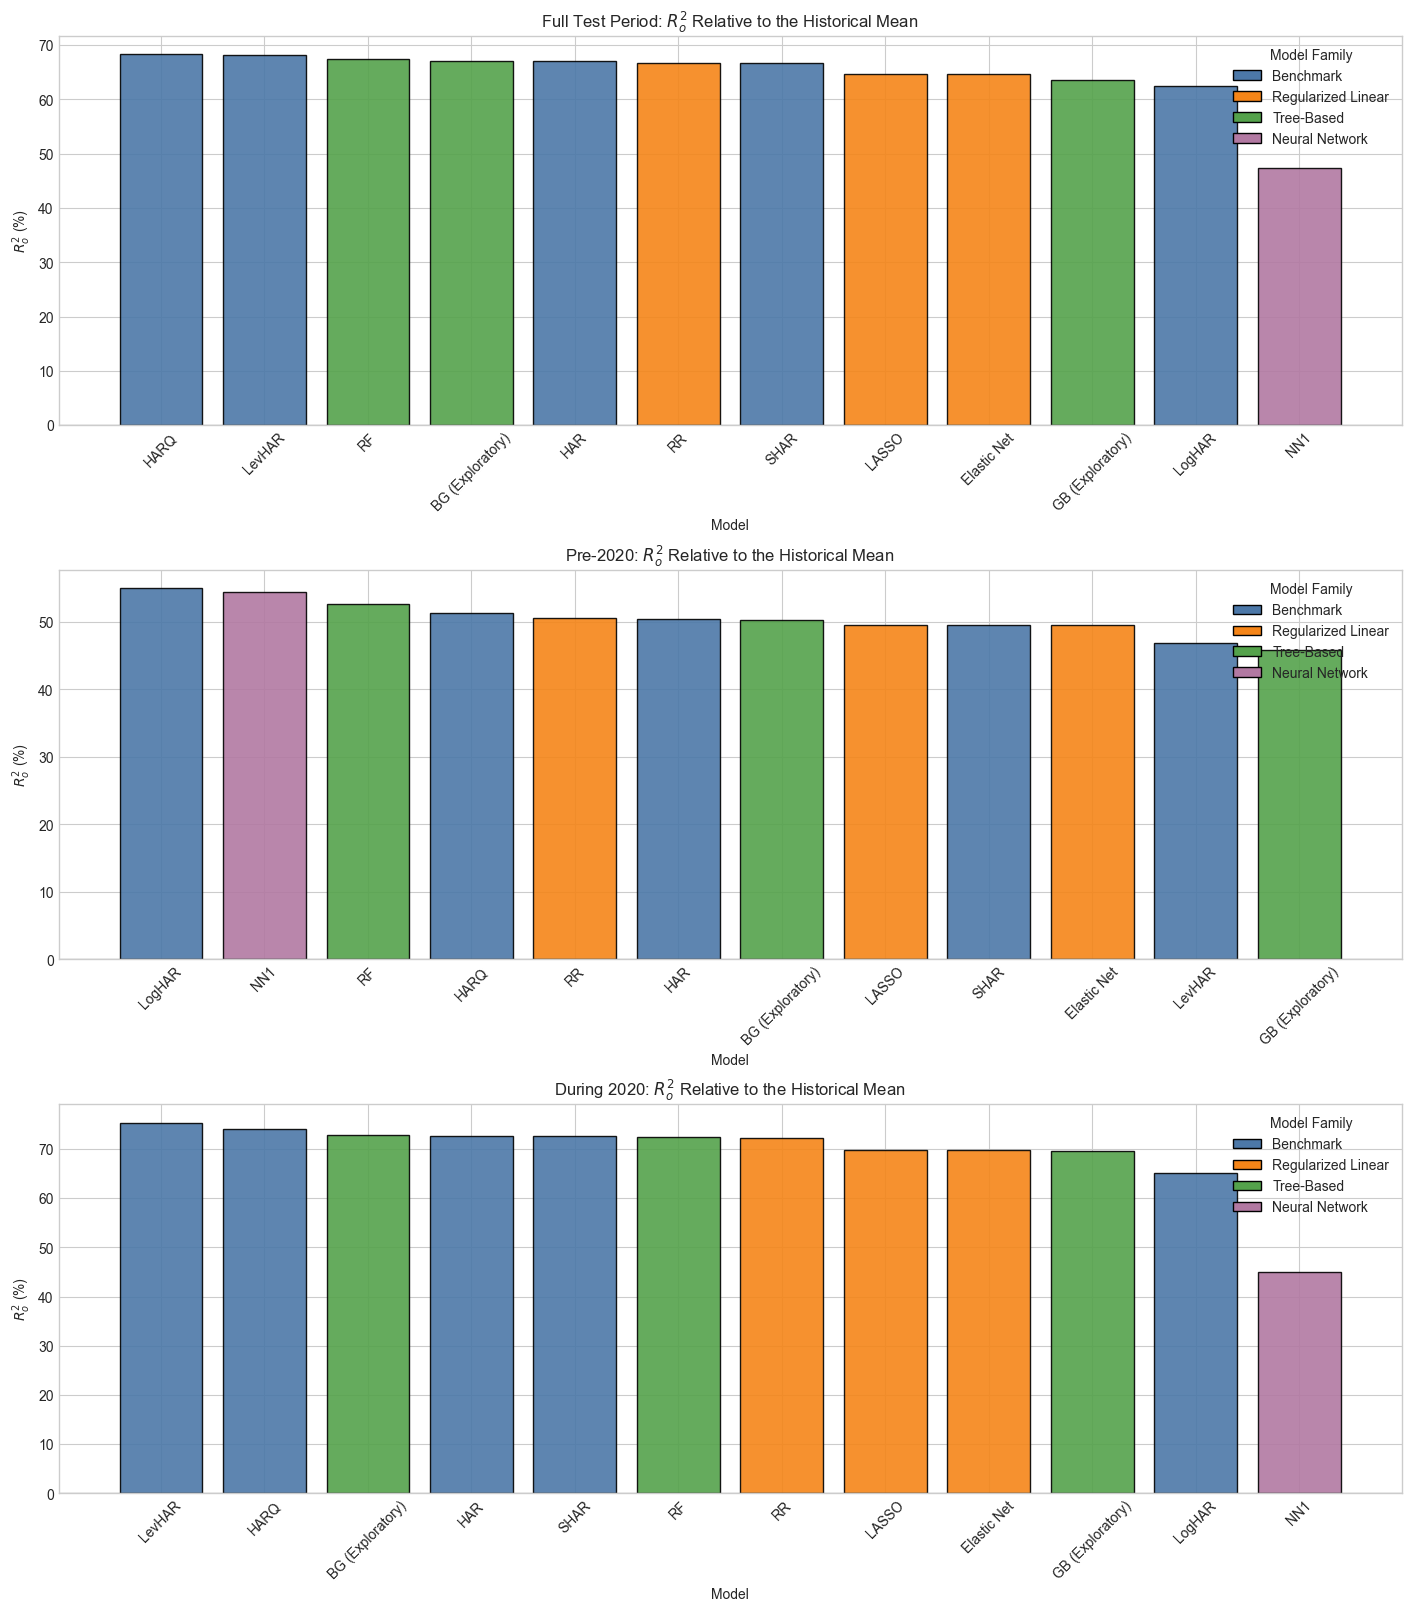

In [9]:
from matplotlib.patches import Patch

plot_periods = {
    'Full Test Period': summary_metrics[['Model', 'Family', 'R_o^2']].copy().sort_values('R_o^2', ascending=False),
    'Pre-2020': subperiod_tables['Pre-2020'][['Model', 'Family', 'R_o^2']].copy().sort_values('R_o^2', ascending=False),
    'During 2020': subperiod_tables['During 2020'][['Model', 'Family', 'R_o^2']].copy().sort_values('R_o^2', ascending=False),
}

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=family)
    for family, color in family_colors.items()
]

fig, axes = plt.subplots(3, 1, figsize=(14, 16), constrained_layout=True)

for ax, (period_name, table) in zip(axes, plot_periods.items()):
    colors = table['Family'].map(family_colors)
    ax.bar(table['Model'], 100 * table['R_o^2'], color=colors, edgecolor='black', alpha=0.9)
    ax.set_title(f'{period_name}: $R_o^2$ Relative to the Historical Mean')
    ax.set_ylabel('$R_o^2$ (%)')
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend(handles=legend_handles, title='Model Family', loc='best')

plt.show()


## 10. Interpreting the “Exploratory” Label for the Tree-Based Models

The exploratory label does **not** mean that the model family changes. Rather, it indicates that the implementation keeps the same forecasting idea as in the reference paper but uses lighter computational settings so the rolling MHAR experiment can be completed in a reasonable amount of time.

In this project, the exploratory label affects the tree-based models as follows:

- **Bagging (Exploratory):** the rolling bagging procedure is preserved, but the number of trees is reduced relative to the paper-faithful specification.
- **Gradient Boosting (Exploratory):** the rolling boosting procedure is preserved, but the hyperparameter search is simplified and the tuning burden is reduced relative to the full reference-paper design.
- **Random Forest:** the saved `RF` result is the standard MHAR random-forest implementation and therefore does not carry the exploratory label.

The small table below provides a supplemental check for bagging by comparing the available full bagging run with the lighter exploratory run.

In [10]:
supplementary_rows = []
for spec in supplementary_specs + [s for s in model_specs if s['key'] == 'BG_exploratory']:
    df = load_forecast_file(forecast_path / f"forecasts_{spec['key']}.csv").reindex(common_index)
    errors = df['RV_actual'] - df['RV_forecast']
    supplementary_rows.append({
        'Model': spec['label'],
        'MSE': np.mean(errors ** 2),
        'RMSE': np.sqrt(np.mean(errors ** 2)),
        'MAE': np.mean(np.abs(errors)),
    })

supplementary_table = pd.DataFrame(supplementary_rows).sort_values('MSE').reset_index(drop=True)
display(
    supplementary_table.style.format({
        'MSE': '{:.6e}',
        'RMSE': '{:.6e}',
        'MAE': '{:.6e}',
    }).set_caption('Supplementary Check: Full versus Exploratory Bagging on the Aligned Window')
)

print('Interpretation: the exploratory label signals a computationally lighter approximation, not a different model family.')


,Model,MSE,RMSE,MAE
0,BG (Exploratory),2.217241e-08,1.489040e-04,5.515754e-05
1,BG (Full),2.231206e-08,1.493722e-04,5.524691e-05


Interpretation: the exploratory label signals a computationally lighter approximation, not a different model family.


## 11. Takeaway

This notebook provides a unified MHAR benchmark comparison across all model families used in the thesis. The summary tables, DM tests, boxplot, $R_o^2$ ranking, and subperiod breakdown can now be used as the empirical foundation for the results discussion in the thesis chapter. The most important caution is that the tree models marked as exploratory remain informative for ranking and interpretation, but they should still be described as computationally lighter approximations of the full reference-paper implementations.